# TMA4135 - Exercise 4
Student: Magnus Ingnes Sagmo

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

## Problem 1 - Bisection Method
Consider the function 
$$
f(x) = (2 - 2 \cdot 3^x) x^2 + 4(2x - 2) 3^x + 4(2 - 2x)
$$

We want to find roots of $f(x)$ in the interal $[-2,3]$

a) Plot the function on the interval $[-2,3]$.

b) _Delivered on paper_

c) _Delivered on paper_

d) _Delivered on paper_

e) Implement the bisection algorithm in python to find roots of $f(x)$ with an error smaller than $10^4$ (again in the interval $[−2, 3]$). Check your result from c).

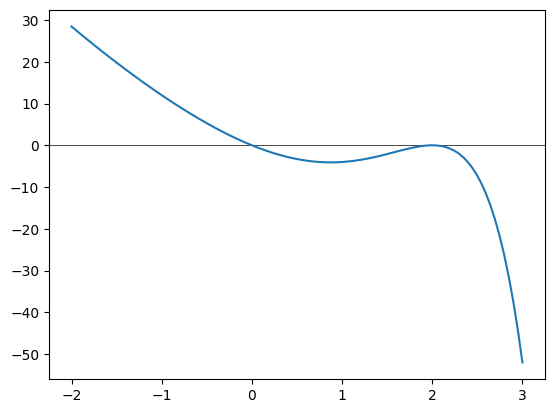

In [2]:
def f(x):
    a = (2 - 2 * (3**x)) * x**2
    b = 4 * (2 * x - 2) * 3**x
    c = 4 * (2 - 2 * x)

    return a + b + c

x_values = np.linspace(-2,3,100)
y_values = list(map(f, x_values))

plt.axhline(0, color='black', linewidth=0.5)
plt.plot(x_values, y_values)

In [3]:
def bisection_method(f, a, b, err_limit):
        err = np.inf
        n = 0
        max_iterations = 1000

        if f(a) * f(b) >= 0:
            raise ValueError("a and b must have oposite signs")
        
        while err > err_limit and n < max_iterations:
            c = (a+b)/2
            val = f(c)

            err = abs(b-a) / 2**n
            
            if err < err_limit:
                return c, n, err
            
            if f(a) * val < 0:
                b = c
            else:
                a = c

            n += 1
        
        raise ValueError(f"No root found within {max_iterations} iterations.")


# Test run with a proper interval:
try:
    root, iterations, final_error = bisection_method(f, -2, 3, 1e-4)
    print(f"Found root {root} in {iterations} iterations, with final error: {final_error}")
except ValueError as e:
    print(e)

Found root 0.001953125 in 8 iterations, with final error: 7.62939453125e-05


## Problem 2 - Fixed-Point Method

In this exercise, we will use fixed-point iterations to find the real root(s) of

$
f(x) = x^2 - 2x - 3 = (x - 3)(x + 1) = 0.
$

To apply the fixed-point algorithm, we first need to rewrite Eq. (1) as $ x = g(x) $, but this representation is not unique. For example, we can write

$
x = \sqrt{2x + 3} := g_1(x), \quad \text{or} \quad x = \frac{x^2 - 3}{2} := g_2(x), \quad \text{or} \quad x = \frac{3}{x - 2} := g_3(x).
$

In fact, the algorithm's convergence (and convergence speed) will depend on whether we choose $ g_1 $, $ g_2 $, or $ g_3 $ as our $ g(x) $. We will experiment with all versions.

a) _Delivered on paper_

b) Set $ x^{(0)} = 4 $ and iterate until $ |x^{(k+1)} - x^{(k)}| < 10^{-6} $ with all the methods. What is the solution obtained, and how many iterations are needed to reach it for the different cases? Comment the results with respect to the expectations you had.




In [4]:
def g1(x):
    if 2*x + 3 == 0:
        raise ValueError(f"Can not take square root of 2{x} + 3")
    return sqrt(2*x + 3)

def g2(x):
    return ((x**2) - 3)/2

def g3(x):
    if x - 2 == 0:
        raise ValueError(f"Can not take square root of 2{x} + 3")
    return 3/(x-2)

In [5]:
def fixed_point_method(g, x0, err_limit):
    err = np.inf
    n = 0
    max_iterations = 10000

    x = x0

    while n < max_iterations:

        val = g(x)

        if abs(val - x) < err_limit:
            return val, n
        
        x = val
        n += 1

    raise RuntimeError(f"No root found within {max_iterations} iterations.")

In [6]:
x0 = 4
err_limit = 1e-6

assert 1e-6 == 10**(-6)

# for g in [g1, g2, g3]:
for g in [g1, g3]:
    root, iterations = fixed_point_method(g, x0, err_limit)
    print(f"Approximated root: {root}, iterations: {iterations}")

Approximated root: 3.0000001935533036, iterations: 13
Approximated root: -0.9999998451295186, iterations: 16


I omit runnig g2, because the absolute value of the dericative of g2 is more than one and it thus will not converge. 

# Problem 3. (Newton’s method - J)

Consider the function  
$f(x) = -x + \cos(x)$.

We want to find the root of $f(x)$.

a) _Delivered on paper_

b) (J) Implement Newton’s method for the problem at hand and use it to find the root of $f(x)$ with error less than $10^{-5}$. Use $x_0 = 0.5$ as the starting point.


In [7]:
def newtons_method(f, f_derivated, x0, err_limit):
    err = np.inf
    n = 0
    max_iterations = 1000000

    x = x0

    while err > err_limit and n < max_iterations:
        val = x - (f(x)/f_derivated(x))

        err = abs(val - x)

        if err < err_limit:
            return val, n, err
        
        x = val
        n += 1

    raise RuntimeError(f"No root found after {max_iterations} iterations")

    

In [8]:
def f(x):
    return -x + np.cos(x)

def f_derivated(x):
    return -np.sin(x) - 1

x0 = 0.5
err_limit = 1e-5

root, iterations, error = newtons_method(f, f_derivated, x0, err_limit)
print(f"Found the root {root} after {iterations} iterations, with the error {error}")

Found the root 0.7390851332151607 after 3 iterations, with the error 7.056460971099909e-10
